# Model C: NFL-Realistic + Team/Conference

# libaries

In [ ]:
#cell 1
import pandas as pd
import glob
import os

import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from collections import Counter
import pickle

# load data

In [ ]:
#cell 2
all_csv_files = (
    glob.glob("../1.Data_Collection_Prep/clean_final_datasets/*.csv"))

In [ ]:
#cell 3
for file in all_csv_files:
    file_name = os.path.splitext(os.path.basename(file))[0]
    globals()[file_name] = pd.read_csv(file)


Loaded 4 CSV files


In [31]:
#cell 4

all_csv_files

['../1.Data_Collection_Prep/clean_final_datasets\\college_performance_history.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\nfl_draft_stats.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\player_master.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\player_personal_data.csv']

In [ ]:
#cell 5

# call dataframe variables
player_personal_data = player_personal_data
college_performance = college_performance_history
player_master = player_master

# Data Info

In [ ]:
# Cell 6: check data structure and NA patterns  
print("College Performance Info:")
print(college_performance.info())
print("\nNA counts in college performance:")
na_counts = college_performance.isnull().sum()
print(na_counts[na_counts > 0].sort_values(ascending=False))
print(f"\nUnique athletes in college data: {college_performance['athlete_id'].nunique()}")


College Performance Info:
<class 'pandas.DataFrame'>
RangeIndex: 102046 entries, 0 to 102045
Data columns (total 60 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 102046 non-null  int64  
 1   team                 102046 non-null  str    
 2   conference           102046 non-null  str    
 3   athlete_id           102046 non-null  int64  
 4   player               102046 non-null  str    
 5   position             102046 non-null  str    
 6   passing_completions  7105 non-null    float64
 7   passing_att          7105 non-null    float64
 8   passing_pct          7105 non-null    float64
 9   passing_yds          7105 non-null    float64
 10  passing_td           7105 non-null    float64
 11  passing_int          7105 non-null    float64
 12  passing_ypa          7105 non-null    float64
 13  rushing_car          22110 non-null   float64
 14  rushing_yds          22110 non-null   float64
 15  ru

# prep data

## create target + features

In [ ]:
# Cell 9:
# binary target: 0=Not drafted, 1=Drafted
target_df = player_master[['athlete_id', 'drafted']].copy()

# Check target distribution
print(f"\nBinary target distribution:")
print(target_df['drafted'].value_counts())
print(f"As percentages:")
print(target_df['drafted'].value_counts(normalize=True))
print(f"\nTarget breakdown:")
print(f"• Not drafted (0): {(target_df['drafted'] == 0).sum():,} players")
print(f"• Drafted (1): {(target_df['drafted'] == 1).sum():,} players")


Binary target distribution:
drafted
0    40577
1     1444
Name: count, dtype: int64
As percentages:
drafted
0    0.965636
1    0.034364
Name: proportion, dtype: float64

Target breakdown:
• Not drafted (0): 40,577 players
• Drafted (1): 1,444 players


In [ ]:
#cell 10
efficiency_columns = [
    'athlete_id',      
    'year',            
    'passing_pct',     
    'passing_ypa',     
    'rushing_ypc',    
    'receiving_ypr',  
    'kicking_pct',    
    'interceptions_avg', 
    'kick_returns_avg',  
    'punt_returns_avg',  
    'punting_ypp'   
]

# + team and conference from college_performance
college_contextual_columns = [
    'athlete_id', 'year', 
    'team', 'conference'   
]

print("Efficiency metrics for Model C:")
for col in efficiency_columns:
    if col in college_performance.columns:
        if col not in ['athlete_id', 'year']:
            non_null = college_performance[col].notna().sum()
            total = len(college_performance)
            print(f"{col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

print("\nContextual features from college data:")
for col in ['team', 'conference']:
    if col in college_performance.columns:
        non_null = college_performance[col].notna().sum()
        total = len(college_performance)
        print(f"{col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

print("\nPhysical features from player_master:")
for col in ['position', 'height', 'weight']:
    if col in player_master.columns:
        non_null = player_master[col].notna().sum()
        total = len(player_master)
        print(f"{col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

model_c_efficiency = college_performance[efficiency_columns].copy()
model_c_contextual = college_performance[college_contextual_columns].copy()

Efficiency metrics for Model C:
passing_pct         :   7105 non-null (  7.0%)
passing_ypa         :   7105 non-null (  7.0%)
rushing_ypc         :  22110 non-null ( 21.7%)
receiving_ypr       :  28027 non-null ( 27.5%)
kicking_pct         :   3248 non-null (  3.2%)
interceptions_avg   :  10206 non-null ( 10.0%)
kick_returns_avg    :   9720 non-null (  9.5%)
punt_returns_avg    :   5209 non-null (  5.1%)
punting_ypp         :   3023 non-null (  3.0%)

Contextual features from college data:
team                : 102046 non-null (100.0%)
conference          : 102046 non-null (100.0%)

Physical features from player_master:
position            :  42021 non-null (100.0%)
height              :  41615 non-null ( 99.0%)
weight              :  41434 non-null ( 98.6%)

Model C efficiency data shape: (102046, 11)
Model C contextual data shape: (102046, 4)


In [ ]:
#cell 11: aggregate features
def aggregate_player_efficiency(df):
    numeric_cols = [col for col in df.columns if col not in ['athlete_id', 'year']]
    
    #  aggregation functions
    agg_functions = {}
    for col in numeric_cols:
        agg_functions[col] = ['mean', 'max', 'min', 'std', 'count']
    
    # agg by athlete_id
    player_agg = df.groupby('athlete_id').agg(agg_functions)

    player_agg.columns = [f"{col[0]}_{col[1]}" for col in player_agg.columns]

    player_agg = player_agg.reset_index()
    return player_agg

def aggregate_contextual_features(df):
    contextual_agg = df.groupby('athlete_id').agg({
        'team': ['nunique', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'],
        'conference': ['nunique', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown']
    })
    
    contextual_agg.columns = ['team_count', 'team_primary', 'conference_count', 'conference_primary']
    contextual_agg = contextual_agg.reset_index()
    return contextual_agg

model_c_efficiency_agg = aggregate_player_efficiency(model_c_efficiency)
print(f"Efficiency features shape: {model_c_efficiency_agg.shape}")

model_c_contextual_agg = aggregate_contextual_features(model_c_contextual)
print(f"Contextual features shape: {model_c_contextual_agg.shape}")

physical_features = player_master[['athlete_id', 'position', 'height', 'weight']].copy()
print(f"Physical features shape: {physical_features.shape}")

print(f"Sample efficiency feature names: {list(model_c_efficiency_agg.columns[1:11])}")
print(f"Contextual feature names: {list(model_c_contextual_agg.columns[1:])}")
print(f"Physical feature names: {list(physical_features.columns[1:])}")

Efficiency features shape: (42021, 46)


Contextual features shape: (42021, 5)
Physical features shape: (42021, 4)
Sample efficiency feature names: ['passing_pct_mean', 'passing_pct_max', 'passing_pct_min', 'passing_pct_std', 'passing_pct_count', 'passing_ypa_mean', 'passing_ypa_max', 'passing_ypa_min', 'passing_ypa_std', 'passing_ypa_count']
Contextual feature names: ['team_count', 'team_primary', 'conference_count', 'conference_primary']
Physical feature names: ['position', 'height', 'weight']


In [ ]:
# Cell 12: merge all features with binary target variable

model_c_features = model_c_efficiency_agg.merge(
    model_c_contextual_agg, on='athlete_id', how='inner'
)
print(f"After merging efficiency + contextual: {model_c_features.shape}")

# +physical features
model_c_features = model_c_features.merge(
    physical_features, on='athlete_id', how='inner'
)
print(f"After adding physical features: {model_c_features.shape}")

# + target variable
final_dataset = model_c_features.merge(
    target_df[['athlete_id', 'drafted']], on='athlete_id', how='inner'
)
print(f"Final Model C dataset shape: {final_dataset.shape}")

print("\nEncoding categorical variables...")
final_dataset_encoded = final_dataset.copy()

position_dummies = pd.get_dummies(final_dataset_encoded['position'], prefix='pos')
final_dataset_encoded = pd.concat([final_dataset_encoded, position_dummies], axis=1)

team_counts = final_dataset_encoded['team_primary'].value_counts()
conf_counts = final_dataset_encoded['conference_primary'].value_counts()
final_dataset_encoded['team_frequency'] = final_dataset_encoded['team_primary'].map(team_counts)
final_dataset_encoded['conference_frequency'] = final_dataset_encoded['conference_primary'].map(conf_counts)

final_dataset_encoded = final_dataset_encoded.drop(['team_primary', 'conference_primary', 'position'], axis=1)

print(f"After encoding categoricals: {final_dataset_encoded.shape}")

# get features and binary target to X and Y
X = final_dataset_encoded.drop(['athlete_id', 'drafted'], axis=1)
y = final_dataset_encoded['drafted']

print(f"\nModel C Feature matrix shape: {X.shape}")
print(f"New features vs Model C: +{X.shape[1] - 34} features")
print(f"Binary target distribution:")
print(y.value_counts())
print(f"Class breakdown: Not drafted: {(y==0).sum()}, Drafted: {(y==1).sum()}")

After merging efficiency + contextual: (42021, 50)
After adding physical features: (42021, 53)
Final Model C dataset shape: (42021, 54)

Encoding categorical variables...
After encoding categoricals: (42021, 79)

Model C Feature matrix shape: (42021, 77)
New features vs Model C: +43 features
Binary target distribution:
drafted
0    40577
1     1444
Name: count, dtype: int64
Class breakdown: Not drafted: 40577, Drafted: 1444


### handle NAs from college history

In [ ]:
# Cell 13: Handle missing values and prepare for modeling

# what percentage of each feature is missing
na_percentages = (X.isnull().sum() / len(X)) * 100
print("Features by percentage of missing values:")
print(na_percentages.sort_values(ascending=False).head(10))

# keep features with <95% missing values
features_to_keep = na_percentages[na_percentages < 95].index.tolist()
print(f"\nKeeping {len(features_to_keep)} features with <95% missing values")

# clean feature matrix
X_clean = X[features_to_keep].copy()
print(f"Clean feature matrix shape: {X_clean.shape}")

# final feature set
print(f"\nFinal Model C features:")
for i, feat in enumerate(X_clean.columns):
    if i % 5 == 0 and i > 0:
        print()  
    print(f"{feat:25}", end=" ")

Features by percentage of missing values:
punting_ypp_std         98.115228
kicking_pct_std         98.072392
punt_returns_avg_std    97.427477
punting_ypp_min         96.461293
punting_ypp_max         96.461293
punting_ypp_mean        96.461293
kicking_pct_mean        96.056734
kicking_pct_min         96.056734
kicking_pct_max         96.056734
passing_pct_std         95.744985
dtype: float64

Keeping 66 features with <95% missing values
Clean feature matrix shape: (42021, 66)

Final Model C features:
passing_pct_mean          passing_pct_max           passing_pct_min           passing_pct_count         passing_ypa_mean          
passing_ypa_max           passing_ypa_min           passing_ypa_count         rushing_ypc_mean          rushing_ypc_max           
rushing_ypc_min           rushing_ypc_std           rushing_ypc_count         receiving_ypr_mean        receiving_ypr_max         
receiving_ypr_min         receiving_ypr_std         receiving_ypr_count       kicking_pct_count    

##  prep data splits

In [ ]:
# Cell 14: Handle missing values and class imbalance

print("Original class distribution:")
print(Counter(y))

# NaN values
print(f"NaN values before imputation: {X_clean.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)
print(f"NaN values after imputation: {X_imputed.isnull().sum().sum()}")

# load universal split
with open('test_train_split/athlete_split.pkl', 'rb') as f:
    split = pickle.load(f)

# split based on athlete_id
train_mask = final_dataset['athlete_id'].isin(split['train_athlete_ids'])
test_mask = final_dataset['athlete_id'].isin(split['test_athlete_ids'])

X_train_pre_smote = X_imputed[train_mask]
X_test = X_imputed[test_mask]
y_train_pre_smote = y[train_mask]
y_test = y[test_mask]

# SMOTE only on training data
smote = SMOTE(
    sampling_strategy={
        0: (y_train_pre_smote==0).sum(), 
        1: min((y_train_pre_smote==0).sum() // 3, 15000)   
    },
    random_state=42,
    k_neighbors=5
)

X_train, y_train = smote.fit_resample(X_train_pre_smote, y_train_pre_smote)

print(f"Training: {X_train_pre_smote.shape[0]} → {X_train.shape[0]} (after SMOTE)")
print(f"Test: {X_test.shape[0]} (unchanged)")
print(f"Training class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")

Original class distribution:
Counter({0: 40577, 1: 1444})
NaN values before imputation: 893149
NaN values after imputation: 0
Applying SMOTE to training data only...
Training: 33616 → 43281 (after SMOTE)
Test: 8405 (unchanged)
Training class distribution: Counter({0: 32461, 1: 10820})
Test class distribution: Counter({0: 8116, 1: 289})


# random forest

## train model

In [ ]:
# Cell 15: train Random Forest
model_a_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=50
)

model_a_rf.fit(X_train, y_train)

# predictions
y_pred = model_a_rf.predict(X_test)
y_pred_proba = model_a_rf.predict_proba(X_test)

print("\nRandom Forest Model C (Draft Prediction) Results:")
print(classification_report(y_test, y_pred, target_names=['Not Drafted', 'Drafted']))

# Binary AUC
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"AUC Score: {auc_score:.4f}")


Training Binary Model C (RF)...

Random Forest Model C (Draft Prediction) Results:
              precision    recall  f1-score   support

 Not Drafted       0.99      0.90      0.94      8116
     Drafted       0.17      0.62      0.27       289

    accuracy                           0.89      8405
   macro avg       0.58      0.76      0.60      8405
weighted avg       0.96      0.89      0.91      8405

AUC Score: 0.8674


## Assess Model

Top 15 Most Important Efficiency Features in Model C:
                    feature  importance
65     conference_frequency    0.110010
64           team_frequency    0.106360
36                   height    0.091252
23  interceptions_avg_count    0.070460
37                   weight    0.065005
35         conference_count    0.055530
34               team_count    0.045261
17      receiving_ypr_count    0.036807
19   interceptions_avg_mean    0.035495
20    interceptions_avg_max    0.033194
22    interceptions_avg_std    0.031672
12        rushing_ypc_count    0.025036
11          rushing_ypc_std    0.022768
53                   pos_ol    0.022023
16        receiving_ypr_std    0.021134


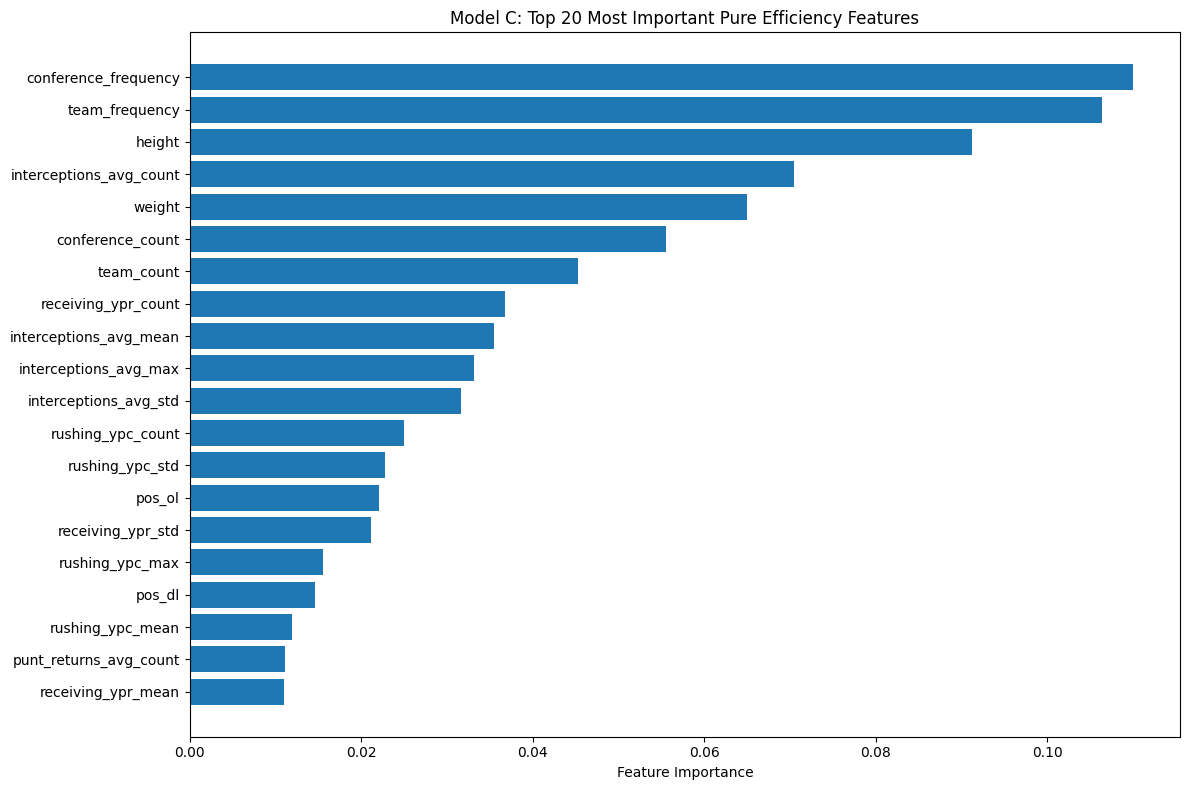

In [ ]:
# Cell 16: feature importance

feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_a_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Efficiency Features in Model C:")
print(feature_importance.head(15))

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Model C: Top 20 Most Important Pure Efficiency Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 16.5

print("\nImportance by feature type:")
feature_types = {
    'Efficiency_Stats': 0,
    'Position_Dummies': 0, 
    'Physical_Attributes': 0,
    'Team_Context': 0,
    'Conference_Context': 0
}

for _, row in feature_importance.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    
    if feature_name.startswith('pos_'):
        feature_types['Position_Dummies'] += importance
    elif feature_name in ['height', 'weight']:
        feature_types['Physical_Attributes'] += importance
    elif 'team' in feature_name.lower():
        feature_types['Team_Context'] += importance
    elif 'conference' in feature_name.lower():
        feature_types['Conference_Context'] += importance
    else:
        feature_types['Efficiency_Stats'] += importance

for feat_type, importance in sorted(feature_types.items(), key=lambda x: x[1], reverse=True):
    print(f"{feat_type:20}: {importance:.4f}")

print("\nTop efficiency metrics (for Model C comparison):")
efficiency_features = feature_importance[
    ~feature_importance['feature'].str.startswith('pos_') &
    ~feature_importance['feature'].isin(['height', 'weight']) &
    ~feature_importance['feature'].str.contains('team|conference', case=False)
].head(10)

for _, row in efficiency_features.iterrows():
    print(f"{row['feature']:30}: {row['importance']:.4f}")


Importance by feature type:
Efficiency_Stats    : 0.4213
Conference_Context  : 0.1655
Physical_Attributes : 0.1563
Team_Context        : 0.1516
Position_Dummies    : 0.1052

Top efficiency metrics (for Model C comparison):
interceptions_avg_count       : 0.0705
receiving_ypr_count           : 0.0368
interceptions_avg_mean        : 0.0355
interceptions_avg_max         : 0.0332
interceptions_avg_std         : 0.0317
rushing_ypc_count             : 0.0250
rushing_ypc_std               : 0.0228
receiving_ypr_std             : 0.0211
rushing_ypc_max               : 0.0155
rushing_ypc_mean              : 0.0120


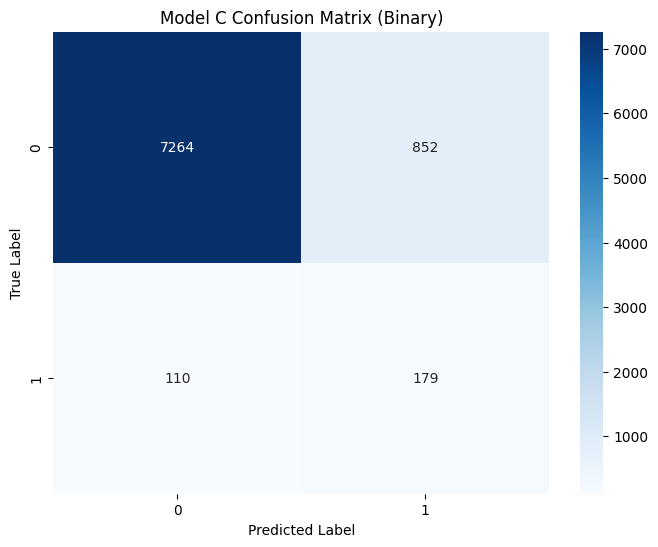

In [ ]:
# Cell 17: confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Model C Confusion Matrix (Binary)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label') 
plt.show()

# XGBoost

In [ ]:
# Cell 18: XGBoost (binary classification)
model_a_xgb = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',  
    objective='binary:logistic'  
)

model_a_xgb.fit(X_train, y_train)



Training Binary Model C (XGBoost)...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:

# Cell 19: predictions
y_pred_xgb = model_a_xgb.predict(X_test)
y_pred_proba_xgb = model_a_xgb.predict_proba(X_test)



In [ ]:
print("\nXGBoost Model C (Draft Prediction) Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Drafted', 'Drafted']))

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"AUC Score: {xgb_auc:.4f}")


XGBoost Model C (Draft Prediction) Results:
              precision    recall  f1-score   support

 Not Drafted       0.97      0.99      0.98      8116
     Drafted       0.39      0.15      0.21       289

    accuracy                           0.96      8405
   macro avg       0.68      0.57      0.60      8405
weighted avg       0.95      0.96      0.95      8405

AUC Score: 0.8906


Top 15 Most Important Features - XGBoost Model C:
                    feature  importance
35         conference_count    0.095597
53                   pos_ol    0.078577
23  interceptions_avg_count    0.048448
36                   height    0.047343
34               team_count    0.044459
17      receiving_ypr_count    0.042142
64           team_frequency    0.040480
11          rushing_ypc_std    0.036594
43                   pos_de    0.035296
65     conference_frequency    0.035065
12        rushing_ypc_count    0.029227
60                   pos_rb    0.028020
61                    pos_s    0.023436
32   punt_returns_avg_count    0.023273
44                   pos_dl    0.022590


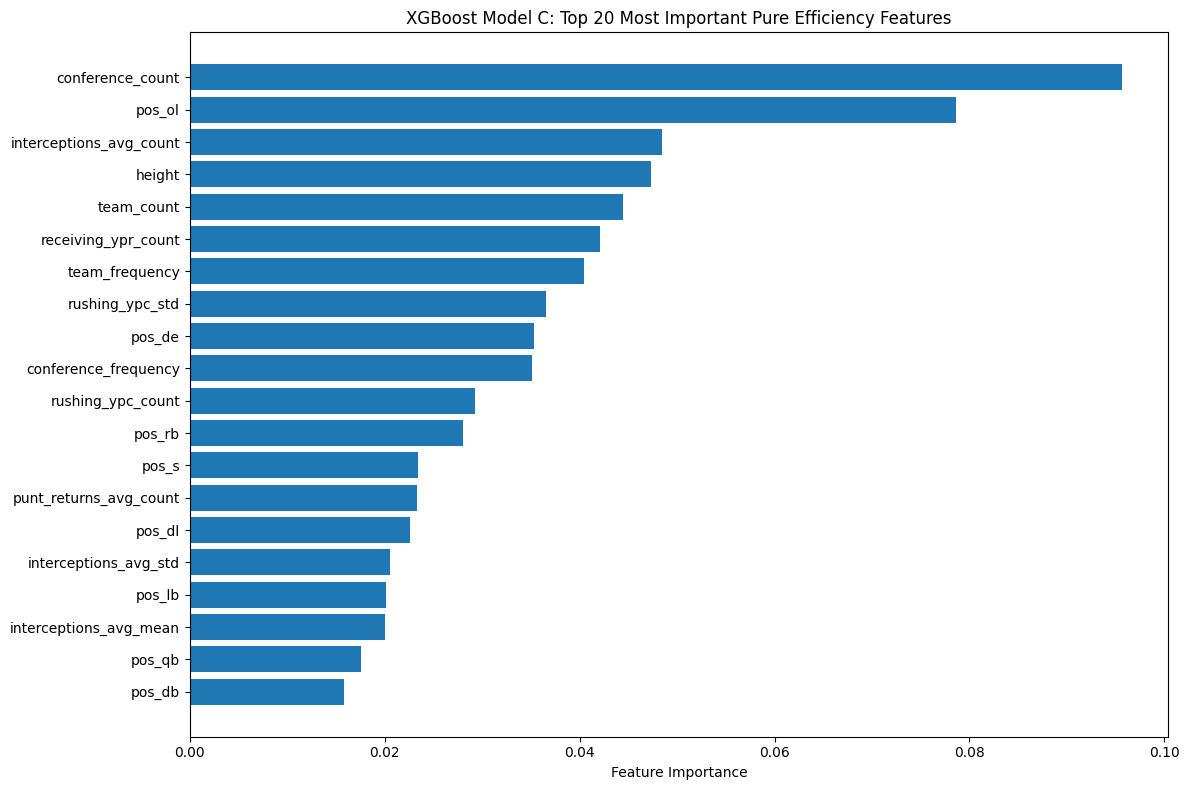

In [ ]:
# Cell 20: XGBoost feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_a_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features - XGBoost Model C:")
print(xgb_feature_importance.head(15))

plt.figure(figsize=(12, 8))
top_features_xgb = xgb_feature_importance.head(20)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'])
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Model C: Top 20 Most Important Pure Efficiency Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# cell 20.5 importance by FEATURE TYPE
print("\nXGBoost Importance by feature type:")
xgb_feature_types = {
    'Efficiency_Stats': 0,
    'Position_Dummies': 0, 
    'Physical_Attributes': 0,
    'Team_Context': 0,
    'Conference_Context': 0
}

for _, row in xgb_feature_importance.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    
    if feature_name.startswith('pos_'):
        xgb_feature_types['Position_Dummies'] += importance
    elif feature_name in ['height', 'weight']:
        xgb_feature_types['Physical_Attributes'] += importance
    elif 'team' in feature_name.lower():
        xgb_feature_types['Team_Context'] += importance
    elif 'conference' in feature_name.lower():
        xgb_feature_types['Conference_Context'] += importance
    else:
        xgb_feature_types['Efficiency_Stats'] += importance

for feat_type, importance in sorted(xgb_feature_types.items(), key=lambda x: x[1], reverse=True):
    print(f"{feat_type:20}: {importance:.4f}")

print("\nTop XGBoost efficiency metrics (for Model C comparison):")
xgb_efficiency_features = xgb_feature_importance[
    ~xgb_feature_importance['feature'].str.startswith('pos_') &
    ~xgb_feature_importance['feature'].isin(['height', 'weight']) &
    ~xgb_feature_importance['feature'].str.contains('team|conference', case=False)
].head(10)

for _, row in xgb_efficiency_features.iterrows():
    print(f"{row['feature']:30}: {row['importance']:.4f}")


XGBoost Importance by feature type:
Efficiency_Stats    : 0.3914
Position_Dummies    : 0.3337
Conference_Context  : 0.1307
Team_Context        : 0.0849
Physical_Attributes : 0.0593

Top XGBoost efficiency metrics (for Model C comparison):
interceptions_avg_count       : 0.0484
receiving_ypr_count           : 0.0421
rushing_ypc_std               : 0.0366
rushing_ypc_count             : 0.0292
punt_returns_avg_count        : 0.0233
interceptions_avg_std         : 0.0205
interceptions_avg_mean        : 0.0200
passing_pct_count             : 0.0157
kick_returns_avg_count        : 0.0148
rushing_ypc_max               : 0.0132


# Compare

In [ ]:
# Cell 21: AUC scores 
rf_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"Random Forest AUC: {rf_auc:.4f}")

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"XGBoost AUC: {xgb_auc:.4f}")

rf_recall_drafted = (y_pred[y_test==1] == 1).mean() if (y_test==1).sum() > 0 else 0
xgb_recall_drafted = (y_pred_xgb[y_test==1] == 1).mean() if (y_test==1).sum() > 0 else 0

print(f"\nRecall for Drafted Players:")
print(f"  Random Forest: {rf_recall_drafted:.1%}")
print(f"  XGBoost:       {xgb_recall_drafted:.1%}")

Calculating AUC scores...
Random Forest AUC: 0.8674
XGBoost AUC: 0.8906

Recall for Drafted Players:
  Random Forest: 61.9%
  XGBoost:       14.5%


In [ ]:
# Cell 22: Performance metrics comparison

print(f"ROC AUC Scores:")
print(f"  Random Forest: {rf_auc:.4f}")
print(f"  XGBoost:       {xgb_auc:.4f}")
print(f"  Difference:    {xgb_auc - rf_auc:+.4f}")

print(f"\nRecall for Drafted Players:")
print(f"  Random Forest: {rf_recall_drafted:.1%}")
print(f"  XGBoost:       {xgb_recall_drafted:.1%}")
print(f"  Difference:    {xgb_recall_drafted - rf_recall_drafted:+.1%}")

Model C COMPARISON: RANDOM FOREST vs XGBOOST (BINARY)
ROC AUC Scores:
  Random Forest: 0.8674
  XGBoost:       0.8906
  Difference:    +0.0232

Recall for Drafted Players:
  Random Forest: 61.9%
  XGBoost:       14.5%
  Difference:    -47.4%


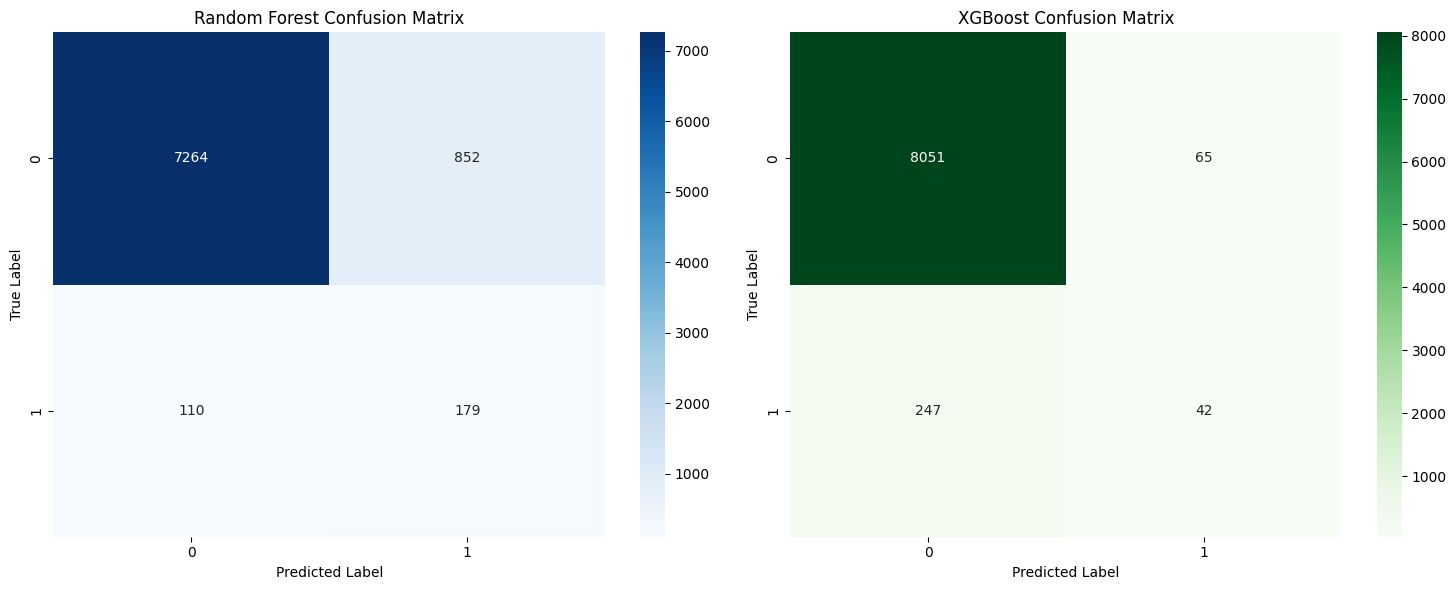

In [51]:
##cell 23 Side by side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Random Forest Confusion Matrix')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# XGBoost confusion matrix  
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('XGBoost Confusion Matrix')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Feature importance correlation between RF and XGBoost: 0.633


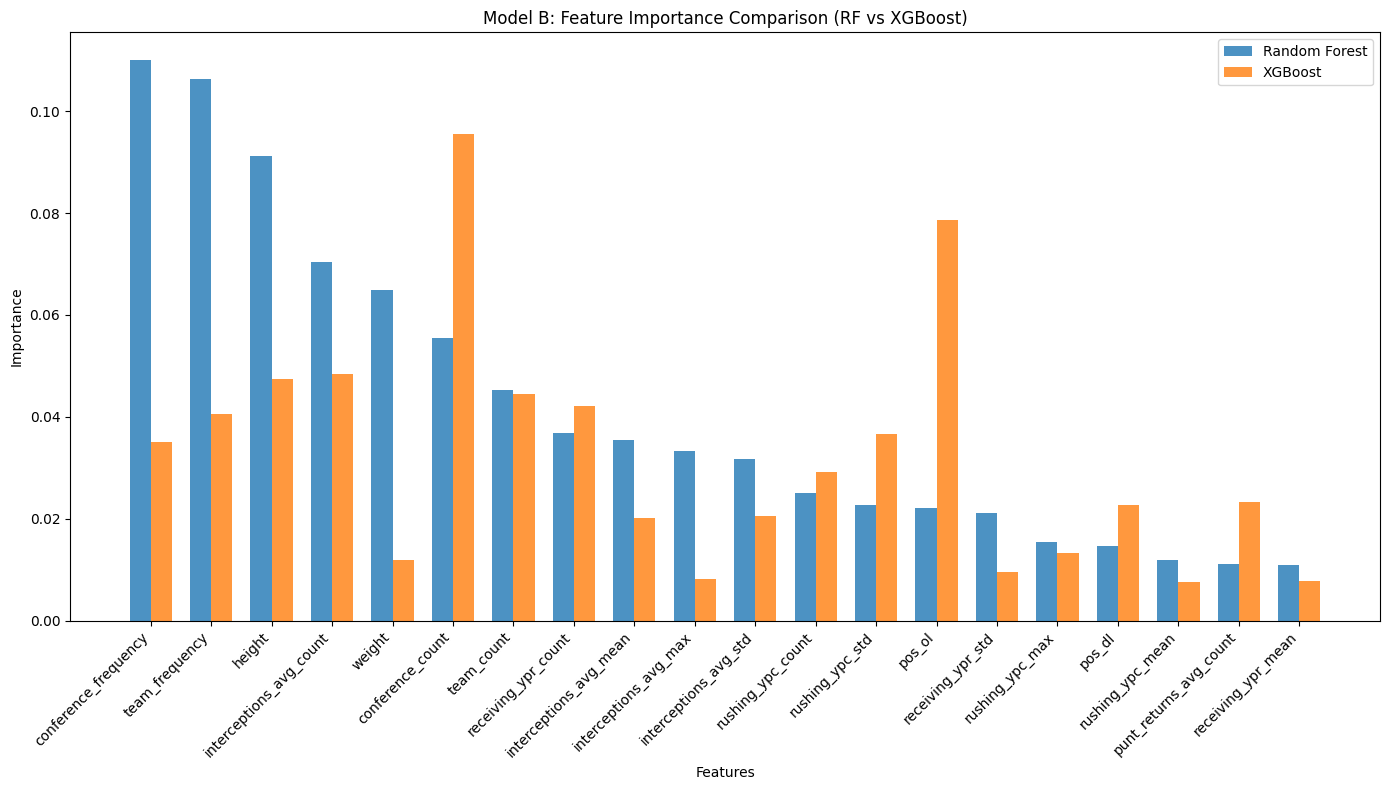


Features where XGBoost and RF disagree most:
XGBoost values higher:
             feature  importance_rf  importance_xgb      diff
13            pos_ol       0.022023        0.078577  0.056553
5   conference_count       0.055530        0.095597  0.040066
20            pos_de       0.010888        0.035296  0.024408
23            pos_rb       0.009441        0.028020  0.018579
29             pos_s       0.007065        0.023436  0.016371

Random Forest values higher:
                 feature  importance_rf  importance_xgb      diff
0   conference_frequency       0.110010        0.035065 -0.074945
1         team_frequency       0.106360        0.040480 -0.065880
4                 weight       0.065005        0.011975 -0.053030
2                 height       0.091252        0.047343 -0.043908
9  interceptions_avg_max       0.033194        0.008135 -0.025059


In [ ]:
# Cell 24: Compare feature importance between RF and XGBoost

importance_comparison = feature_importance.merge(
    xgb_feature_importance, 
    on='feature', 
    suffixes=('_rf', '_xgb')
)

# correlation between feature importances
importance_corr = importance_comparison[['importance_rf', 'importance_xgb']].corr().iloc[0,1]
print(f"Feature importance correlation between RF and XGBoost: {importance_corr:.3f}")

# Plot comparison 
plt.figure(figsize=(14, 8))
top_20_comparison = importance_comparison.head(20)

x = range(len(top_20_comparison))
width = 0.35

plt.bar([i - width/2 for i in x], top_20_comparison['importance_rf'], 
        width, label='Random Forest', alpha=0.8)
plt.bar([i + width/2 for i in x], top_20_comparison['importance_xgb'], 
        width, label='XGBoost', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Model B: Feature Importance Comparison (RF vs XGBoost)')
plt.xticks(x, top_20_comparison['feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

importance_comparison['diff'] = importance_comparison['importance_xgb'] - importance_comparison['importance_rf']
print("\nFeatures where XGBoost and RF disagree most:")
print("XGBoost values higher:")
print(importance_comparison.nlargest(5, 'diff')[['feature', 'importance_rf', 'importance_xgb', 'diff']])
print("\nRandom Forest values higher:")
print(importance_comparison.nsmallest(5, 'diff')[['feature', 'importance_rf', 'importance_xgb', 'diff']])

In [ ]:
# Cell 25: Final summary 

print(f"Dataset Overview:")
print(f"• Total players: {X_clean.shape[0]:,}")
print(f"• Features: {X_clean.shape[1]} efficiency and physical metrics")
print(f"• Drafted players: {y.sum():,} ({y.mean():.1%})")
print(f"• Class imbalance ratio: {(y==0).sum()//y.sum()}:1")

print(f"\nModel Performance Comparison:")
print(f"{'Metric':<25} {'Random Forest':<15} {'XGBoost':<15} {'Winner'}")
print(f"{'-'*65}")
print(f"{'ROC AUC':<25} {rf_auc:<15.4f} {xgb_auc:<15.4f} {'XGBoost' if xgb_auc > rf_auc else 'RF'}")
print(f"{'Drafted Recall':<25} {rf_recall_drafted:<15.1%} {xgb_recall_drafted:<15.1%} {'XGBoost' if xgb_recall_drafted > rf_recall_drafted else 'RF'}")

print(f"\nTop Performance Drivers (both models agree):")
common_top_features = set(feature_importance.head(10)['feature']) & set(xgb_feature_importance.head(10)['feature'])
for i, feat in enumerate(sorted(common_top_features)[:5], 1):
    print(f"{i}. {feat}")
    

FINAL MODEL C SUMMARY: EFFICIENCY + PHYSICAL FEATURES + CONFERENCE/TEAM CONTEXT
Dataset Overview:
• Total players: 42,021
• Features: 66 efficiency and physical metrics
• Drafted players: 1,444 (3.4%)
• Class imbalance ratio: 28:1

Model Performance Comparison:
Metric                    Random Forest   XGBoost         Winner
-----------------------------------------------------------------
ROC AUC                   0.8674          0.8906          XGBoost
Drafted Recall            61.9%           14.5%           RF

Top Performance Drivers (both models agree):
1. conference_count
2. conference_frequency
3. height
4. interceptions_avg_count
5. receiving_ypr_count

Key Findings:
• Pure efficiency metrics achieve 89.1% AUC
• Can identify ~62% of drafted players
• XGBoost performs slightly better
• Feature importance correlation: 63.3% (models largely agree)


# save results

In [ ]:

MODEL_SET_NAME = "Model_C"   # change per notebook

results_df = pd.DataFrame({
    "athlete_id": final_dataset.loc[X_test.index, "athlete_id"].values,
    "true_label": y_test.values,

    # Random Forest
    "rf_pred": y_pred,
    "rf_pred_proba": y_pred_proba[:, 1],

    # XGBoost
    "xgb_pred": y_pred_xgb,
    "xgb_pred_proba": y_pred_proba_xgb[:, 1],
})

results_df["model_set"] = MODEL_SET_NAME

os.makedirs("model_results", exist_ok=True)

output_path = f"model_results/{MODEL_SET_NAME}_results.csv"
results_df.to_csv(output_path, index=False)

print(f"saved to: {output_path}")

✅ Results saved to: model_results/Model_C_results.csv
Shape: (8405, 7)
